# 19. Stable Diffusion Classical Metrics

This notebook computes classical image restoration metrics for the Stable Diffusion Inpainting baseline on the controlled 50-painting subset.

The metrics are computed between:

- clean reference and damaged input,
- clean reference and Stable Diffusion restored output.

The goal is to evaluate whether Stable Diffusion improves over the damaged input under pixel-level and structural metrics.

## Metric design

Classical metrics are computed over the same regions used for OpenCV Telea and LaMa:

- `full_image`,
- `content_region`,
- `masked_region`,
- `mask_bbox_crop`.

The masked region is the most direct local evaluation region because it measures only the synthetically damaged area.

Zero-control cases are included for full-image and content-region sanity checks, but they do not produce masked-region or mask-bounding-box rows because they contain no damaged pixels.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import yaml

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from restoration_eval.metrics_classical import (
    compute_classical_metrics_for_restorations,
    summarize_classical_metrics,
    validate_classical_metrics,
)

print("Project root:", PROJECT_ROOT)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
config_path = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

paths_cfg = config["paths"]

processed_metadata_dir = PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
figures_dir = PROJECT_ROOT / paths_cfg["figures_dir"]

metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

restored_metadata_path = processed_metadata_dir / "metadata_restored_stable_diffusion.csv"
processed_clean_metadata_path = processed_metadata_dir / "metadata_processed_clean.csv"

classical_metrics_path = metrics_dir / "classical_metrics_stable_diffusion_50.csv"
summary_by_mask_type_path = metrics_dir / "classical_metrics_summary_by_mask_type_stable_diffusion_50.csv"
summary_by_category_path = metrics_dir / "classical_metrics_summary_by_category_stable_diffusion_50.csv"
summary_by_region_path = metrics_dir / "classical_metrics_summary_by_region_stable_diffusion_50.csv"
summary_by_region_mask_type_path = metrics_dir / "classical_metrics_summary_by_region_mask_type_stable_diffusion_50.csv"
masked_region_summary_path = metrics_dir / "classical_metrics_masked_region_summary_stable_diffusion_50.csv"

strongest_cases_path = metrics_dir / "stable_diffusion_strongest_masked_region_cases_50.csv"
weakest_cases_path = metrics_dir / "stable_diffusion_weakest_masked_region_cases_50.csv"

visual_cases_manifest_path = metrics_dir / "stable_diffusion_classical_metric_visual_cases_manifest_50.csv"
visual_cases_dir = figures_dir / "stable_diffusion_classical_metric_cases"
visual_cases_dir.mkdir(parents=True, exist_ok=True)

model_name = "stable_diffusion_inpainting"
target_size = 768
mask_bbox_margin = 8

print("Restored metadata:", restored_metadata_path)
print("Processed clean metadata:", processed_clean_metadata_path)
print("Classical metrics output:", classical_metrics_path)
print("Visual cases dir:", visual_cases_dir)

Restored metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_stable_diffusion.csv
Processed clean metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
Classical metrics output: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_stable_diffusion_50.csv
Visual cases dir: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\stable_diffusion_classical_metric_cases


In [3]:
if not restored_metadata_path.exists():
    raise FileNotFoundError(f"Stable Diffusion restored metadata not found: {restored_metadata_path}")

if not processed_clean_metadata_path.exists():
    raise FileNotFoundError(f"Processed clean metadata not found: {processed_clean_metadata_path}")

stable_diffusion_restored_df = pd.read_csv(restored_metadata_path)
processed_clean_df = pd.read_csv(processed_clean_metadata_path)

metadata_columns = [
    "painting_id",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_metadata_columns = [
    column for column in metadata_columns
    if column not in processed_clean_df.columns
]

if missing_metadata_columns:
    raise ValueError(
        f"Processed clean metadata missing columns: {missing_metadata_columns}"
    )

columns_to_drop_before_merge = [
    column
    for column in [
        "category",
        "title",
        "content_x_min",
        "content_y_min",
        "content_x_max",
        "content_y_max",
    ]
    if column in stable_diffusion_restored_df.columns
]

stable_diffusion_cases_df = stable_diffusion_restored_df.drop(
    columns=columns_to_drop_before_merge
).merge(
    processed_clean_df[metadata_columns],
    on="painting_id",
    how="left",
    validate="many_to_one",
)

print("Stable Diffusion restored metadata shape:", stable_diffusion_restored_df.shape)
print("Enriched Stable Diffusion cases shape:", stable_diffusion_cases_df.shape)

display(stable_diffusion_cases_df.head())

print("\nModel name counts:")
display(stable_diffusion_cases_df["model_name"].value_counts(dropna=False))

print("\nInference mode counts:")
display(stable_diffusion_cases_df["inference_mode"].value_counts(dropna=False))

print("\nMask type counts:")
display(stable_diffusion_cases_df["mask_type"].value_counts().sort_index())

print("\nCategory counts:")
display(stable_diffusion_cases_df["category"].value_counts().sort_index())

Stable Diffusion restored metadata shape: (250, 36)
Enriched Stable Diffusion cases shape: (250, 42)


,case_id,painting_id,mask_id,mask_type,clean_filename,clean_path,mask_filename,mask_path,damaged_filename,damaged_path,...,case_runtime_seconds,restored_width,restored_height,restored_mode,category,title,content_x_min,content_y_min,content_x_max,content_y_max
0,p001_loss_large,p001,p001_loss_large,loss_large,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,6.554261,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768
1,p001_loss_small,p001,p001_loss_small,loss_small,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,6.619525,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,6.606830,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,6.153014,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768
4,p001_zero_control,p001,p001_zero_control,zero_control,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,0.000000,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768



Model name counts:


model_name
stable_diffusion_inpainting    250
Name: count, dtype: int64


Inference mode counts:


inference_mode
model_inference        200
copied_zero_control     50
Name: count, dtype: int64


Mask type counts:


mask_type
loss_large      50
loss_small      50
mixed_damage    50
scratch_thin    50
zero_control    50
Name: count, dtype: int64


Category counts:


category
abstraction_surrealism     50
architecture_structured    50
high_texture_brushwork     50
landscape_natural          50
portrait_figure            50
Name: count, dtype: int64

In [4]:
required_case_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "model_name",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
    "status",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_case_columns = [
    column for column in required_case_columns
    if column not in stable_diffusion_cases_df.columns
]

if missing_case_columns:
    raise ValueError(f"Stable Diffusion cases missing columns: {missing_case_columns}")

if len(stable_diffusion_cases_df) != 250:
    raise ValueError(
        f"Expected 250 Stable Diffusion cases, found {len(stable_diffusion_cases_df)}."
    )

if stable_diffusion_cases_df["case_id"].duplicated().any():
    duplicated_cases = stable_diffusion_cases_df[
        stable_diffusion_cases_df["case_id"].duplicated(keep=False)
    ]
    display(duplicated_cases)
    raise ValueError("Stable Diffusion metadata contains duplicate case_id values.")

if set(stable_diffusion_cases_df["model_name"].dropna().unique()) != {model_name}:
    raise ValueError(
        f"Unexpected model names: {stable_diffusion_cases_df['model_name'].unique()}"
    )

if (stable_diffusion_cases_df["status"] != "ok").any():
    display(stable_diffusion_cases_df[stable_diffusion_cases_df["status"] != "ok"])
    raise ValueError("Stable Diffusion metadata contains non-ok rows.")

expected_mask_counts = {
    "loss_large": 50,
    "loss_small": 50,
    "mixed_damage": 50,
    "scratch_thin": 50,
    "zero_control": 50,
}

actual_mask_counts = stable_diffusion_cases_df["mask_type"].value_counts().to_dict()

print("Expected mask counts:", expected_mask_counts)
print("Actual mask counts:", actual_mask_counts)

for mask_type, expected_count in expected_mask_counts.items():
    actual_count = actual_mask_counts.get(mask_type, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 50,
    "landscape_natural": 50,
    "architecture_structured": 50,
    "abstraction_surrealism": 50,
    "high_texture_brushwork": 50,
}

actual_category_counts = stable_diffusion_cases_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Category {category!r}: expected {expected_count}, found {actual_count}."
        )

def resolve_project_path(path_value: str | Path) -> Path:
    path = Path(str(path_value))

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path

for path_column in ["clean_path", "damaged_path", "restored_path", "mask_path"]:
    missing_paths = [
        resolve_project_path(path)
        for path in stable_diffusion_cases_df[path_column]
        if str(path).strip() == "" or not resolve_project_path(path).exists()
    ]

    print(path_column, "missing files:", len(missing_paths))

    if missing_paths:
        raise FileNotFoundError(
            f"Missing files in {path_column!r}: {missing_paths[:10]}"
        )

print("\nStable Diffusion classical-metric metadata gates passed.")

Expected mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}
Actual mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}

Expected category counts: {'portrait_figure': 50, 'landscape_natural': 50, 'architecture_structured': 50, 'abstraction_surrealism': 50, 'high_texture_brushwork': 50}
Actual category counts: {'portrait_figure': 50, 'landscape_natural': 50, 'architecture_structured': 50, 'abstraction_surrealism': 50, 'high_texture_brushwork': 50}
clean_path missing files: 0
damaged_path missing files: 0
restored_path missing files: 0
mask_path missing files: 0

Stable Diffusion classical-metric metadata gates passed.


In [8]:
stable_diffusion_cases_abs_df = stable_diffusion_cases_df.copy()

path_columns_to_resolve = [
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

for path_column in path_columns_to_resolve:
    stable_diffusion_cases_abs_df[path_column] = stable_diffusion_cases_abs_df[path_column].map(
        lambda value: str(resolve_project_path(value))
    )

for path_column in path_columns_to_resolve:
    missing_paths = [
        path
        for path in stable_diffusion_cases_abs_df[path_column]
        if str(path).strip() == "" or not Path(path).exists()
    ]

    print(path_column, "missing files after absolute-path conversion:", len(missing_paths))

    if missing_paths:
        raise FileNotFoundError(
            f"Missing files after absolute-path conversion in {path_column!r}: "
            f"{missing_paths[:10]}"
        )

print("Absolute-path Stable Diffusion metric input dataframe ready.")
display(
    stable_diffusion_cases_abs_df[
        [
            "case_id",
            "painting_id",
            "mask_type",
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ].head()
)

clean_path missing files after absolute-path conversion: 0
damaged_path missing files after absolute-path conversion: 0
restored_path missing files after absolute-path conversion: 0
mask_path missing files after absolute-path conversion: 0
Absolute-path Stable Diffusion metric input dataframe ready.


,case_id,painting_id,mask_type,clean_path,damaged_path,restored_path,mask_path
0,p001_loss_large,p001,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_loss_small,p001,loss_small,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p001_mixed_damage,p001,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p001_scratch_thin,p001,scratch_thin,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p001_zero_control,p001,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


In [9]:
smoke_nonzero_df = (
    stable_diffusion_cases_abs_df[
        stable_diffusion_cases_abs_df["mask_type"] != "zero_control"
    ]
    .sort_values(["painting_id", "mask_type"])
    .head(1)
    .copy()
)

smoke_zero_control_df = (
    stable_diffusion_cases_abs_df[
        stable_diffusion_cases_abs_df["mask_type"] == "zero_control"
    ]
    .sort_values(["painting_id", "mask_type"])
    .head(1)
    .copy()
)

smoke_cases_df = pd.concat(
    [smoke_nonzero_df, smoke_zero_control_df],
    ignore_index=True,
)

print("Smoke-test cases:")
display(
    smoke_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ]
)

smoke_classical_df = compute_classical_metrics_for_restorations(
    smoke_cases_df,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    progress_every=1,
)

print("Smoke classical metrics shape:", smoke_classical_df.shape)

display(
    smoke_classical_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "evaluation_region",
            "damaged_mse",
            "restored_mse",
            "mse_improvement",
            "damaged_psnr",
            "restored_psnr",
            "psnr_improvement",
            "status",
        ]
    ]
)

Smoke-test cases:


,case_id,painting_id,category,mask_type,clean_path,damaged_path,restored_path,mask_path
0,p001_loss_large,p001,portrait_figure,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_zero_control,p001,portrait_figure,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


Starting classical metric computation
  Cases: 2
  Target size: 768
  Mask bbox margin: 8
  Expected metric rows: 900 for the full 50-painting experiment
Computing classical metrics for case 1/2 (p001_loss_large) | elapsed 0.00s
Computing classical metrics for case 2/2 (p001_zero_control) | elapsed 2.19s
Classical metric computation complete
  Runtime: 4.01 seconds
  Output rows: 6
  Region counts:
evaluation_region
full_image        2
content_region    2
masked_region     1
mask_bbox_crop    1
  Status counts:
status
ok    6
Smoke classical metrics shape: (6, 30)


,case_id,painting_id,category,mask_type,evaluation_region,damaged_mse,restored_mse,mse_improvement,damaged_psnr,restored_psnr,psnr_improvement,status
0,p001_loss_large,p001,portrait_figure,loss_large,full_image,5585.921387,137.712723,5448.208664,10.659855,26.741063,16.081208,ok
1,p001_loss_large,p001,portrait_figure,loss_large,content_region,6470.570801,157.467209,6313.103592,10.021378,26.158902,16.137525,ok
2,p001_loss_large,p001,portrait_figure,loss_large,masked_region,48997.804688,864.774048,48133.030640,1.229037,18.761777,17.532740,ok
3,p001_loss_large,p001,portrait_figure,loss_large,mask_bbox_crop,25993.767578,495.236664,25498.530914,3.982111,21.182676,17.200564,ok
4,p001_zero_control,p001,portrait_figure,zero_control,full_image,0.000000,0.000000,0.000000,inf,inf,NaN,ok
5,p001_zero_control,p001,portrait_figure,zero_control,content_region,0.000000,0.000000,0.000000,inf,inf,NaN,ok


In [11]:
classical_metrics_df = compute_classical_metrics_for_restorations(
    stable_diffusion_cases_abs_df,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    progress_every=25,
)

print("Stable Diffusion classical metrics shape:", classical_metrics_df.shape)

display(classical_metrics_df.head())

print("\nMetric status counts:")
display(classical_metrics_df["status"].value_counts(dropna=False))

print("\nEvaluation region counts:")
display(classical_metrics_df["evaluation_region"].value_counts())

print("\nMask type counts:")
display(classical_metrics_df["mask_type"].value_counts())

print("\nCategory counts:")
display(classical_metrics_df["category"].value_counts())

Starting classical metric computation
  Cases: 250
  Target size: 768
  Mask bbox margin: 8
  Expected metric rows: 900 for the full 50-painting experiment
Computing classical metrics for case 1/250 (p001_loss_large) | elapsed 0.00s
Computing classical metrics for case 25/250 (p005_zero_control) | elapsed 48.74s
Computing classical metrics for case 50/250 (p010_zero_control) | elapsed 100.12s
Computing classical metrics for case 75/250 (p015_zero_control) | elapsed 148.81s
Computing classical metrics for case 100/250 (p020_zero_control) | elapsed 197.84s
Computing classical metrics for case 125/250 (p025_zero_control) | elapsed 248.56s
Computing classical metrics for case 150/250 (p030_zero_control) | elapsed 297.40s
Computing classical metrics for case 175/250 (p035_zero_control) | elapsed 353.08s
Computing classical metrics for case 200/250 (p040_zero_control) | elapsed 405.81s
Computing classical metrics for case 225/250 (p045_zero_control) | elapsed 457.44s
Computing classical metr

,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,restored_mae,mae_improvement,damaged_psnr,restored_psnr,psnr_improvement,damaged_ssim,restored_ssim,ssim_improvement,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,stable_diffusion_inpainting,full_image,589824,0.0,...,6.236044,18.822454,10.659855,26.741063,16.081208,0.897178,0.816961,-0.080217,ok,
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,stable_diffusion_inpainting,content_region,509184,52.0,...,6.727410,22.299629,10.021378,26.158902,16.137525,0.880745,0.794350,-0.086395,ok,
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,stable_diffusion_inpainting,masked_region,67242,NaN,...,19.113932,200.690710,1.229037,18.761777,17.532740,NaN,NaN,NaN,ok,
3,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,stable_diffusion_inpainting,mask_bbox_crop,126750,221.0,...,12.929867,103.678425,3.982111,21.182676,17.200564,0.512661,0.631288,0.118627,ok,
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,stable_diffusion_inpainting,full_image,589824,0.0,...,3.940423,4.923999,15.279670,31.984701,16.705031,0.953800,0.852229,-0.101571,ok,



Metric status counts:


status
ok    900
Name: count, dtype: int64


Evaluation region counts:


evaluation_region
full_image        250
content_region    250
masked_region     200
mask_bbox_crop    200
Name: count, dtype: int64


Mask type counts:


mask_type
loss_large      200
loss_small      200
mixed_damage    200
scratch_thin    200
zero_control    100
Name: count, dtype: int64


Category counts:


category
portrait_figure            180
landscape_natural          180
architecture_structured    180
abstraction_surrealism     180
high_texture_brushwork     180
Name: count, dtype: int64

In [12]:
classical_metrics_df.to_csv(classical_metrics_path, index=False)

if not classical_metrics_path.exists():
    raise FileNotFoundError(f"Classical metrics file was not saved: {classical_metrics_path}")

saved_classical_metrics_df = pd.read_csv(classical_metrics_path)

if len(saved_classical_metrics_df) != 900:
    raise ValueError(
        f"Expected 900 saved classical metric rows, found {len(saved_classical_metrics_df)}."
    )

print("Saved Stable Diffusion classical metrics:")
print(classical_metrics_path)

print("Saved rows:", len(saved_classical_metrics_df))

Saved Stable Diffusion classical metrics:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_stable_diffusion_50.csv
Saved rows: 900


In [13]:
summary_by_mask_type_df = summarize_classical_metrics(
    classical_metrics_df,
    group_columns=["mask_type"],
)

summary_by_category_df = summarize_classical_metrics(
    classical_metrics_df,
    group_columns=["category"],
)

summary_by_region_df = summarize_classical_metrics(
    classical_metrics_df,
    group_columns=["evaluation_region"],
)

summary_by_region_mask_type_df = summarize_classical_metrics(
    classical_metrics_df,
    group_columns=["evaluation_region", "mask_type"],
)

masked_region_summary_df = summarize_classical_metrics(
    classical_metrics_df[
        classical_metrics_df["evaluation_region"] == "masked_region"
    ],
    group_columns=["mask_type"],
)

print("Summary by mask type:")
display(summary_by_mask_type_df)

print("\nSummary by category:")
display(summary_by_category_df)

print("\nSummary by evaluation region:")
display(summary_by_region_df)

print("\nSummary by evaluation region and mask type:")
display(summary_by_region_mask_type_df)

print("\nMasked-region summary by mask type:")
display(masked_region_summary_df)

Summary by mask type:


,mask_type,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,loss_large,200,50,11323.9828,1167.2633,10156.7194,65.5425,18.8411,46.7015,10.0675,19.7510,9.6835,0.8031,0.6208,-0.1823,304707.235
1,loss_small,200,50,7656.2517,360.1767,7296.0750,43.9286,10.8754,33.0531,14.2766,24.5905,10.3139,0.9478,0.6973,-0.2506,334144.560
2,mixed_damage,200,50,8715.1308,589.5748,8125.5559,49.2290,13.2985,35.9305,12.0471,22.1922,10.1451,0.8917,0.6703,-0.2215,384264.205
3,scratch_thin,200,50,7605.5491,912.2667,6693.2824,41.6982,16.2838,25.4143,16.8189,22.2158,5.3969,0.9411,0.6827,-0.2584,373697.085
4,zero_control,100,50,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,522240.000



Summary by category:


,category,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,abstraction_surrealism,180,50,5931.7555,875.1538,5056.6017,36.4359,14.8175,21.6183,14.7821,21.3744,6.5923,0.9203,0.7350,-0.1853,392566.9000
1,architecture_structured,180,50,7612.3012,566.1776,7046.1236,44.7338,12.0825,32.6513,13.1676,22.7326,9.5650,0.9090,0.7177,-0.1914,357633.6389
2,high_texture_brushwork,180,50,7923.2860,573.4511,7349.8349,46.0922,12.7094,33.3828,12.8508,22.4414,9.5906,0.9098,0.6837,-0.2261,371109.8500
3,landscape_natural,180,50,6464.3338,676.2542,5788.0796,39.8556,13.9525,25.9031,14.3116,21.5675,7.2559,0.9124,0.6815,-0.2309,350709.4500
4,portrait_figure,180,50,11291.5616,674.8317,10616.7299,55.5473,12.3257,43.2215,11.4005,22.8209,11.4204,0.9026,0.7583,-0.1443,370128.0333



Summary by evaluation region:


,evaluation_region,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,content_region,250,250,1572.5250,237.1863,1335.3386,8.9654,7.7177,1.2477,16.6442,24.1639,7.5198,0.9367,0.7271,-0.2096,454656.000
1,full_image,250,250,1203.4601,186.6272,1016.8329,6.8572,6.3777,0.4795,17.8125,25.2516,7.4391,0.9506,0.7871,-0.1635,589824.000
2,mask_bbox_crop,200,200,4835.2005,545.3732,4289.8273,27.8695,12.5755,15.2940,14.4229,22.8108,8.3879,0.8288,0.6106,-0.2182,318789.815
3,masked_region,200,200,26995.7325,1954.1414,25041.5911,152.7505,29.1041,123.6465,4.3305,16.5232,12.1927,NaN,NaN,NaN,33543.270



Summary by evaluation region and mask type:


,evaluation_region,mask_type,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,content_region,loss_large,50,50,3298.9742,449.2082,2849.7660,19.0271,11.0468,7.9803,13.5845,22.3592,8.7747,0.9031,0.6517,-0.2514,454656.00
1,content_region,loss_small,50,50,1185.8752,187.8962,997.9790,6.7963,8.4230,-1.6267,17.9830,26.0539,8.0709,0.9555,0.6811,-0.2743,454656.00
2,content_region,mixed_damage,50,50,2744.7069,307.7190,2436.9879,15.5419,10.0290,5.5129,14.2714,23.6281,9.3567,0.8852,0.6446,-0.2406,454656.00
3,content_region,scratch_thin,50,50,633.0685,241.1082,391.9603,3.4620,9.0898,-5.6278,20.7378,24.6145,3.8767,0.9395,0.6579,-0.2815,454656.00
4,content_region,zero_control,50,50,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,454656.00
5,full_image,loss_large,50,50,2550.7766,359.4050,2191.3715,14.7026,9.0789,5.6237,14.7528,23.4758,8.7229,0.9253,0.7289,-0.1964,589824.00
6,full_image,loss_small,50,50,901.8392,147.0965,754.7428,5.1609,7.0036,-1.8427,19.1513,27.1001,7.9488,0.9662,0.7519,-0.2143,589824.00
7,full_image,mixed_damage,50,50,2083.1693,236.9194,1846.2499,11.7803,8.2518,3.5285,15.4397,24.7307,9.2910,0.9105,0.7226,-0.1878,589824.00
8,full_image,scratch_thin,50,50,481.5154,189.7150,291.8004,2.6420,7.5542,-4.9122,21.9061,25.6997,3.7937,0.9510,0.7320,-0.2189,589824.00
9,full_image,zero_control,50,50,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,589824.00



Masked-region summary by mask type:


,mask_type,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,loss_large,50,50,25580.7229,2456.2937,23124.4291,148.1165,33.1949,114.9217,4.5927,15.4167,10.8240,NaN,NaN,NaN,58769.48
1,loss_small,50,50,26519.8804,883.1812,25636.6992,152.0709,18.9522,133.1187,4.3729,19.8759,15.5031,NaN,NaN,NaN,19951.84
2,mixed_damage,50,50,27237.5939,1502.5608,25735.0331,153.7445,24.8676,128.8769,4.2923,16.8108,12.5185,NaN,NaN,NaN,45450.92
3,scratch_thin,50,50,28644.7328,2974.5301,25670.2027,157.0701,39.4016,117.6685,4.0641,13.9892,9.9251,NaN,NaN,NaN,10000.84


In [14]:
summary_by_mask_type_df.to_csv(summary_by_mask_type_path, index=False)
summary_by_category_df.to_csv(summary_by_category_path, index=False)
summary_by_region_df.to_csv(summary_by_region_path, index=False)
summary_by_region_mask_type_df.to_csv(summary_by_region_mask_type_path, index=False)
masked_region_summary_df.to_csv(masked_region_summary_path, index=False)

summary_paths = [
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    masked_region_summary_path,
]

print("Saved Stable Diffusion classical metric summaries:")

for path in summary_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing saved summary file: {path}")
    print(path)

Saved Stable Diffusion classical metric summaries:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_summary_by_mask_type_stable_diffusion_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_summary_by_category_stable_diffusion_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_summary_by_region_stable_diffusion_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_summary_by_region_mask_type_stable_diffusion_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_masked_region_summary_stable_diffusion_50.csv


In [15]:
masked_region_df = classical_metrics_df[
    classical_metrics_df["evaluation_region"] == "masked_region"
].copy()

if len(masked_region_df) != 200:
    raise ValueError(
        f"Expected 200 masked-region rows, found {len(masked_region_df)}."
    )

strongest_cases_df = (
    masked_region_df
    .sort_values("mse_improvement", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

weakest_cases_df = (
    masked_region_df
    .sort_values("mse_improvement", ascending=True)
    .head(20)
    .reset_index(drop=True)
)

strongest_cases_df.to_csv(strongest_cases_path, index=False)
weakest_cases_df.to_csv(weakest_cases_path, index=False)

display_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_type",
    "evaluation_region",
    "damaged_mse",
    "restored_mse",
    "mse_improvement",
    "damaged_psnr",
    "restored_psnr",
    "psnr_improvement",
]

print("Strongest Stable Diffusion masked-region MSE improvement cases:")
display(strongest_cases_df[display_columns])

print("\nWeakest Stable Diffusion masked-region MSE improvement cases:")
display(weakest_cases_df[display_columns])

print("\nSaved strongest cases:")
print(strongest_cases_path)

print("\nSaved weakest cases:")
print(weakest_cases_path)

Strongest Stable Diffusion masked-region MSE improvement cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,damaged_mse,restored_mse,mse_improvement,damaged_psnr,restored_psnr,psnr_improvement
0,p006_mixed_damage,p006,portrait_figure,Boy with a Sword,mixed_damage,masked_region,51966.468750,1276.484253,50689.984497,0.973572,17.070649,16.097077
1,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_large,masked_region,51229.851562,705.605164,50524.246399,1.035573,19.645186,18.609613
2,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,mixed_damage,masked_region,50740.699219,913.970337,49826.728882,1.077239,18.521483,17.444243
3,p006_loss_small,p006,portrait_figure,Boy with a Sword,loss_small,masked_region,49847.976562,54.004242,49793.972321,1.154328,30.806525,29.652197
4,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,masked_region,48997.804688,864.774048,48133.030640,1.229037,18.761777,17.532740
5,p006_loss_large,p006,portrait_figure,Boy with a Sword,loss_large,masked_region,52182.812500,4377.602539,47805.209961,0.955529,11.718440,10.762912
6,p001_loss_small,p001,portrait_figure,Juan de Pareja,loss_small,masked_region,46995.500000,82.743462,46912.756538,1.410241,28.953467,27.543226
7,p002_scratch_thin,p002,portrait_figure,Madame X (Madame Pierre Gautreau),scratch_thin,masked_region,50183.656250,3695.871582,46487.784668,1.125181,12.453635,11.328454
8,p002_loss_small,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_small,masked_region,45094.363281,105.003929,44989.359352,1.589581,27.918748,26.329167
9,p006_scratch_thin,p006,portrait_figure,Boy with a Sword,scratch_thin,masked_region,51070.074219,6142.541504,44927.532715,1.049139,10.247323,9.198184



Weakest Stable Diffusion masked-region MSE improvement cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,damaged_mse,restored_mse,mse_improvement,damaged_psnr,restored_psnr,psnr_improvement
0,p036_scratch_thin,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",scratch_thin,masked_region,2009.945190,9849.736328,-7839.791138,15.098961,8.196558,-6.902404
1,p036_loss_large,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_large,masked_region,5263.032715,6783.639160,-1520.606445,10.918443,9.816176,-1.102267
2,p032_scratch_thin,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,scratch_thin,masked_region,5889.045898,6026.027344,-136.981445,10.430354,10.330493,-0.099862
3,p032_mixed_damage,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,mixed_damage,masked_region,2763.684326,878.481506,1885.202820,13.715919,18.693477,4.977558
4,p036_mixed_damage,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",mixed_damage,masked_region,4701.547852,1958.115356,2743.432495,11.408395,15.212421,3.804026
5,p036_loss_small,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_small,masked_region,3290.943359,61.608589,3229.334770,12.957600,30.234391,17.276791
6,p020_loss_large,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,loss_large,masked_region,6440.327148,3168.481934,3271.845215,10.041724,13.122291,3.080567
7,p020_loss_small,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,loss_small,masked_region,4237.945801,437.394104,3800.551697,11.859250,21.722074,9.862825
8,p020_mixed_damage,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,mixed_damage,masked_region,4976.781738,935.545715,4041.236023,11.161318,18.420153,7.258836
9,p042_loss_large,p042,high_texture_brushwork,View of Beirut,loss_large,masked_region,5220.112793,120.236244,5099.876549,10.954005,27.330450,16.376445



Saved strongest cases:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_strongest_masked_region_cases_50.csv

Saved weakest cases:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_weakest_masked_region_cases_50.csv


In [16]:
expected_saved_files = [
    classical_metrics_path,
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    masked_region_summary_path,
    strongest_cases_path,
    weakest_cases_path,
]

for output_file in expected_saved_files:
    if not output_file.exists():
        raise FileNotFoundError(f"Missing expected output file: {output_file}")

saved_strongest_df = pd.read_csv(strongest_cases_path)
saved_weakest_df = pd.read_csv(weakest_cases_path)

if len(saved_strongest_df) != 20:
    raise ValueError(
        f"Expected 20 strongest cases, found {len(saved_strongest_df)}."
    )

if len(saved_weakest_df) != 20:
    raise ValueError(
        f"Expected 20 weakest cases, found {len(saved_weakest_df)}."
    )

if len(pd.read_csv(masked_region_summary_path)) != 4:
    raise ValueError("Masked-region summary should contain 4 non-zero mask types.")

print("Saved Stable Diffusion classical metric summaries and rankings passed validation.")

Saved Stable Diffusion classical metric summaries and rankings passed validation.


In [17]:
strongest_visual_df = strongest_cases_df.head(5).copy()
strongest_visual_df["selection_reason"] = "Strongest masked-region MSE improvement"

weakest_visual_df = weakest_cases_df.head(5).copy()
weakest_visual_df["selection_reason"] = "Weakest masked-region MSE improvement"

category_examples_df = (
    masked_region_df
    .sort_values("mse_improvement", ascending=False)
    .groupby("category", dropna=False)
    .head(1)
    .copy()
)

category_examples_df["selection_reason"] = "Strong category example by masked-region MSE improvement"

visual_cases_raw_df = pd.concat(
    [
        strongest_visual_df,
        weakest_visual_df,
        category_examples_df,
    ],
    ignore_index=True,
)

reason_df = (
    visual_cases_raw_df
    .groupby("case_id")
    .agg(
        selection_reason=("selection_reason", lambda values: "; ".join(sorted(set(values))))
    )
    .reset_index()
)

visual_case_base_columns = [
    column for column in visual_cases_raw_df.columns
    if column != "selection_reason"
]

visual_cases_df = (
    visual_cases_raw_df[visual_case_base_columns]
    .drop_duplicates(subset=["case_id"])
    .merge(reason_df, on="case_id", how="left")
    .sort_values(["category", "mask_type", "case_id"])
    .reset_index(drop=True)
)

print("Selected classical metric visual cases:", len(visual_cases_df))

display(
    visual_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "selection_reason",
            "damaged_mse",
            "restored_mse",
            "mse_improvement",
            "damaged_psnr",
            "restored_psnr",
            "psnr_improvement",
        ]
    ]
)

Selected classical metric visual cases: 14


,case_id,painting_id,category,title,mask_type,selection_reason,damaged_mse,restored_mse,mse_improvement,damaged_psnr,restored_psnr,psnr_improvement
0,p036_loss_large,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_large,Weakest masked-region MSE improvement,5263.032715,6783.639160,-1520.606445,10.918443,9.816176,-1.102267
1,p037_loss_large,p037,abstraction_surrealism,In the Sea,loss_large,Strong category example by masked-region MSE i...,33494.566406,1358.860840,32135.705566,2.881060,16.799054,13.917994
2,p032_mixed_damage,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,mixed_damage,Weakest masked-region MSE improvement,2763.684326,878.481506,1885.202820,13.715919,18.693477,4.977558
3,p036_mixed_damage,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",mixed_damage,Weakest masked-region MSE improvement,4701.547852,1958.115356,2743.432495,11.408395,15.212421,3.804026
4,p032_scratch_thin,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,scratch_thin,Weakest masked-region MSE improvement,5889.045898,6026.027344,-136.981445,10.430354,10.330493,-0.099862
5,p036_scratch_thin,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",scratch_thin,Weakest masked-region MSE improvement,2009.945190,9849.736328,-7839.791138,15.098961,8.196558,-6.902404
6,p022_loss_small,p022,architecture_structured,"Interior of a Protestant, Gothic Church, with ...",loss_small,Strong category example by masked-region MSE i...,37372.199219,1078.512207,36293.687012,2.405317,17.802553,15.397236
7,p050_scratch_thin,p050,high_texture_brushwork,Landscape with a Sunlit Stream,scratch_thin,Strong category example by masked-region MSE i...,42905.945312,3832.838135,39073.107178,1.805629,12.295599,10.489970
8,p013_loss_large,p013,landscape_natural,Landscape with a Village in the Distance,loss_large,Strong category example by masked-region MSE i...,46091.917969,1272.348389,44819.569580,1.494556,17.084743,15.590187
9,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,Strongest masked-region MSE improvement,48997.804688,864.774048,48133.030640,1.229037,18.761777,17.532740


In [18]:
from PIL import Image
import matplotlib.pyplot as plt


def load_project_rgb(path_value: str | Path) -> Image.Image:
    path = resolve_project_path(path_value)

    if not path.exists():
        raise FileNotFoundError(f"Missing image file: {path}")

    return Image.open(path).convert("RGB")


def load_project_mask(path_value: str | Path) -> Image.Image:
    path = resolve_project_path(path_value)

    if not path.exists():
        raise FileNotFoundError(f"Missing mask file: {path}")

    return Image.open(path).convert("L")


def save_classical_metric_visual_case_figure(
    row: pd.Series,
    *,
    output_dir: Path,
) -> Path:
    clean_img = load_project_rgb(row["clean_path"])
    damaged_img = load_project_rgb(row["damaged_path"])
    restored_img = load_project_rgb(row["restored_path"])
    mask_img = load_project_mask(row["mask_path"])

    figure_path = output_dir / f"{row['case_id']}_stable_diffusion_classical_metrics.png"

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(clean_img)
    axes[0].set_title("Clean reference")
    axes[0].axis("off")

    axes[1].imshow(mask_img, cmap="gray")
    axes[1].set_title("Mask")
    axes[1].axis("off")

    axes[2].imshow(damaged_img)
    axes[2].set_title("Damaged input")
    axes[2].axis("off")

    axes[3].imshow(restored_img)
    axes[3].set_title("Stable Diffusion restored")
    axes[3].axis("off")

    metric_text = (
        f"Case: {row['case_id']}\n"
        f"Category: {row['category']}\n"
        f"Mask: {row['mask_type']}\n\n"
        f"Damaged MSE: {row['damaged_mse']:.4f}\n"
        f"Restored MSE: {row['restored_mse']:.4f}\n"
        f"MSE improvement: {row['mse_improvement']:.4f}\n\n"
        f"Damaged PSNR: {row['damaged_psnr']:.4f}\n"
        f"Restored PSNR: {row['restored_psnr']:.4f}\n"
        f"PSNR improvement: {row['psnr_improvement']:.4f}\n\n"
        f"Reason:\n{row['selection_reason']}"
    )

    axes[4].text(
        0.02,
        0.98,
        metric_text,
        va="top",
        ha="left",
        fontsize=9,
        family="monospace",
        transform=axes[4].transAxes,
    )
    axes[4].set_title("Masked-region metrics")
    axes[4].axis("off")

    fig.suptitle(
        f"{row['case_id']} | {row['title']} | {row['mask_type']}",
        fontsize=12,
    )

    plt.tight_layout()
    fig.savefig(figure_path, dpi=140, bbox_inches="tight")
    plt.close(fig)

    return figure_path


print("Stable Diffusion classical visual helper ready.")

Stable Diffusion classical visual helper ready.


In [20]:
path_merge_columns = [
    "case_id",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

# Use absolute-path dataframe so plotting works regardless of notebook working directory.
path_lookup_df = stable_diffusion_cases_abs_df[path_merge_columns].copy()

# Drop stale path columns if any exist, then merge cleanly.
existing_path_columns = [
    column
    for column in ["clean_path", "damaged_path", "restored_path", "mask_path"]
    if column in visual_cases_df.columns
]

visual_cases_df = visual_cases_df.drop(columns=existing_path_columns).merge(
    path_lookup_df,
    on="case_id",
    how="left",
    validate="one_to_one",
)

required_visual_path_columns = [
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

missing_path_values = visual_cases_df[
    required_visual_path_columns
].isna().sum()

print("Missing merged path values:")
display(missing_path_values)

for path_column in required_visual_path_columns:
    if visual_cases_df[path_column].isna().any():
        raise ValueError(f"Missing merged values in {path_column!r}.")

    missing_files = [
        path
        for path in visual_cases_df[path_column]
        if str(path).strip() == "" or not Path(path).exists()
    ]

    print(path_column, "missing files:", len(missing_files))

    if missing_files:
        raise FileNotFoundError(
            f"Missing files in {path_column!r}: {missing_files[:10]}"
        )

print("Visual cases now include valid image paths.")
display(
    visual_cases_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ].head()
)

Missing merged path values:


clean_path       0
damaged_path     0
restored_path    0
mask_path        0
dtype: int64

clean_path missing files: 0
damaged_path missing files: 0
restored_path missing files: 0
mask_path missing files: 0
Visual cases now include valid image paths.


,case_id,category,mask_type,selection_reason,clean_path,damaged_path,restored_path,mask_path
0,p036_loss_large,abstraction_surrealism,loss_large,Weakest masked-region MSE improvement,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p037_loss_large,abstraction_surrealism,loss_large,Strong category example by masked-region MSE i...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p032_mixed_damage,abstraction_surrealism,mixed_damage,Weakest masked-region MSE improvement,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p036_mixed_damage,abstraction_surrealism,mixed_damage,Weakest masked-region MSE improvement,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p032_scratch_thin,abstraction_surrealism,scratch_thin,Weakest masked-region MSE improvement,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


In [21]:
visual_figure_paths = []

for index, row in visual_cases_df.iterrows():
    figure_path = save_classical_metric_visual_case_figure(
        row,
        output_dir=visual_cases_dir,
    )

    visual_figure_paths.append(str(figure_path))

    if (index + 1) % 5 == 0 or (index + 1) == len(visual_cases_df):
        print(
            f"Generated {index + 1}/{len(visual_cases_df)} "
            "Stable Diffusion classical visual figures..."
        )

visual_cases_df["visual_figure_path"] = visual_figure_paths

visual_cases_df.to_csv(visual_cases_manifest_path, index=False)

print("\nSaved Stable Diffusion classical visual manifest:")
print(visual_cases_manifest_path)

print("Generated visual figures:", len(visual_figure_paths))

display(
    visual_cases_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "visual_figure_path",
        ]
    ]
)

Generated 5/14 Stable Diffusion classical visual figures...
Generated 10/14 Stable Diffusion classical visual figures...
Generated 14/14 Stable Diffusion classical visual figures...

Saved Stable Diffusion classical visual manifest:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_classical_metric_visual_cases_manifest_50.csv
Generated visual figures: 14


,case_id,category,mask_type,selection_reason,visual_figure_path
0,p036_loss_large,abstraction_surrealism,loss_large,Weakest masked-region MSE improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p037_loss_large,abstraction_surrealism,loss_large,Strong category example by masked-region MSE i...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p032_mixed_damage,abstraction_surrealism,mixed_damage,Weakest masked-region MSE improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p036_mixed_damage,abstraction_surrealism,mixed_damage,Weakest masked-region MSE improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p032_scratch_thin,abstraction_surrealism,scratch_thin,Weakest masked-region MSE improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
5,p036_scratch_thin,abstraction_surrealism,scratch_thin,Weakest masked-region MSE improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
6,p022_loss_small,architecture_structured,loss_small,Strong category example by masked-region MSE i...,D:\Masters\FH\Thesis\painting-restoration-eval...
7,p050_scratch_thin,high_texture_brushwork,scratch_thin,Strong category example by masked-region MSE i...,D:\Masters\FH\Thesis\painting-restoration-eval...
8,p013_loss_large,landscape_natural,loss_large,Strong category example by masked-region MSE i...,D:\Masters\FH\Thesis\painting-restoration-eval...
9,p001_loss_large,portrait_figure,loss_large,Strongest masked-region MSE improvement,D:\Masters\FH\Thesis\painting-restoration-eval...


Displaying sample classical metric visual figures: 4


,case_id,category,mask_type,selection_reason,visual_figure_path
1,p037_loss_large,abstraction_surrealism,loss_large,Strong category example by masked-region MSE i...,D:\Masters\FH\Thesis\painting-restoration-eval...
13,p006_mixed_damage,portrait_figure,mixed_damage,Strong category example by masked-region MSE i...,D:\Masters\FH\Thesis\painting-restoration-eval...
9,p001_loss_large,portrait_figure,loss_large,Strongest masked-region MSE improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
0,p036_loss_large,abstraction_surrealism,loss_large,Weakest masked-region MSE improvement,D:\Masters\FH\Thesis\painting-restoration-eval...


Displaying p037_loss_large | abstraction_surrealism | loss_large | Strong category example by masked-region MSE improvement


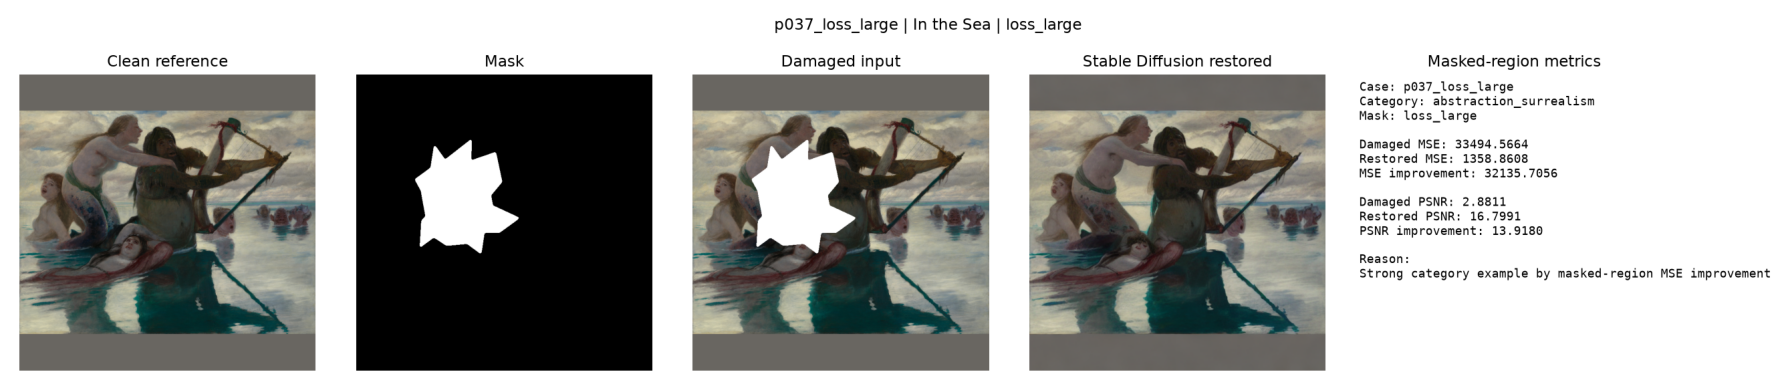

Displaying p006_mixed_damage | portrait_figure | mixed_damage | Strong category example by masked-region MSE improvement; Strongest masked-region MSE improvement


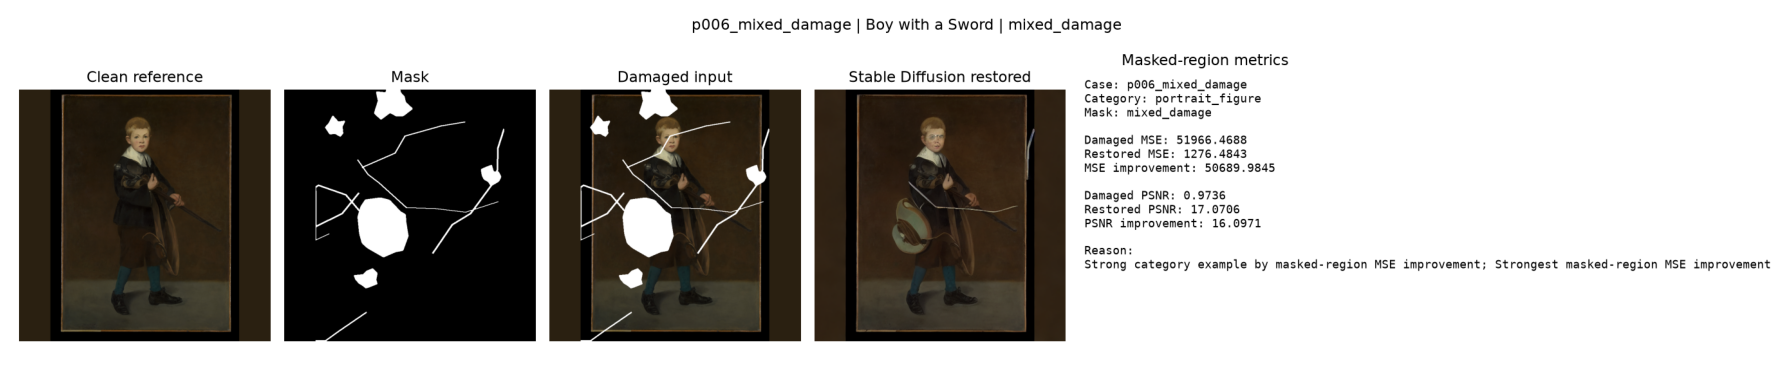

Displaying p001_loss_large | portrait_figure | loss_large | Strongest masked-region MSE improvement


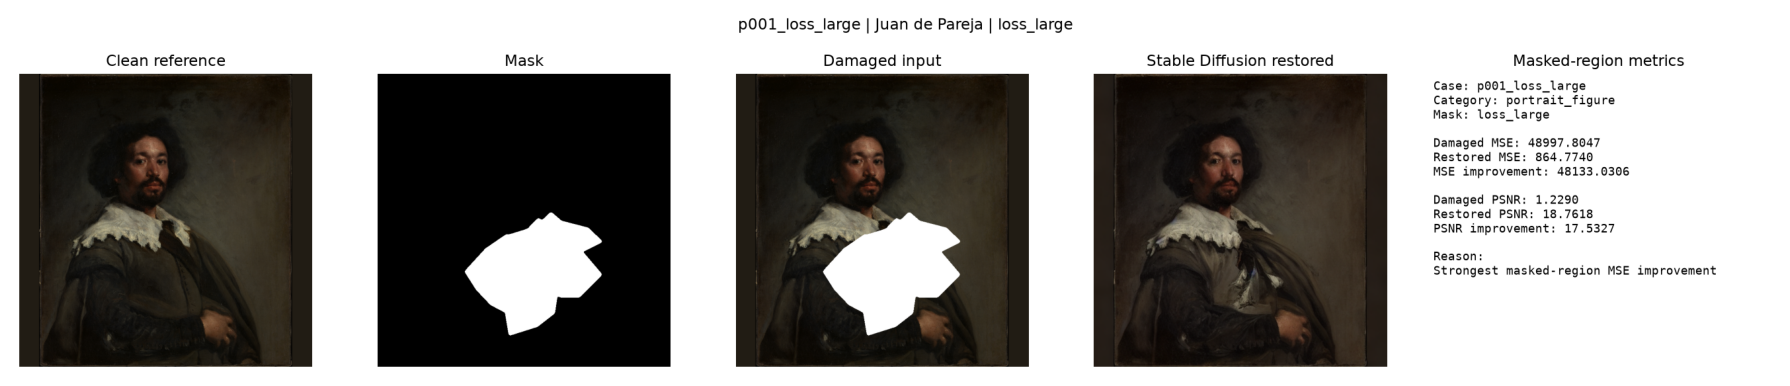

Displaying p036_loss_large | abstraction_surrealism | loss_large | Weakest masked-region MSE improvement


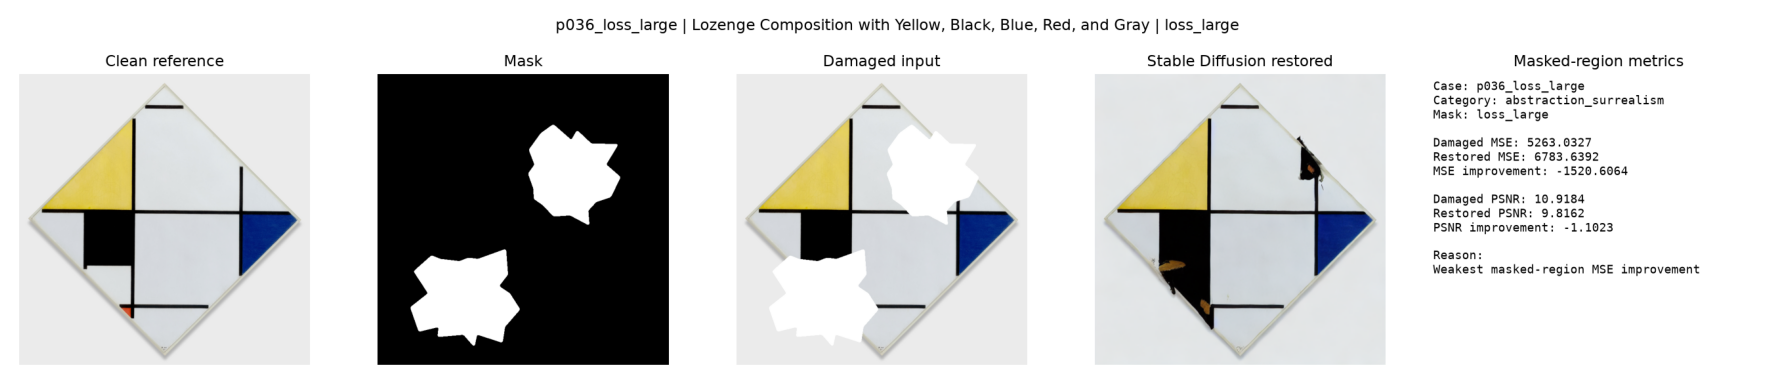

In [22]:
def display_saved_figure(path_value: str | Path) -> None:
    figure_path = Path(path_value)

    if not figure_path.exists():
        raise FileNotFoundError(f"Missing figure: {figure_path}")

    figure_img = Image.open(figure_path).convert("RGB")

    plt.figure(figsize=(18, 5))
    plt.imshow(figure_img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


sample_visual_df = (
    visual_cases_df
    .sort_values(["selection_reason", "category", "mask_type", "case_id"])
    .groupby("selection_reason", dropna=False)
    .head(1)
    .copy()
)

print("Displaying sample classical metric visual figures:", len(sample_visual_df))

display(
    sample_visual_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "visual_figure_path",
        ]
    ]
)

for _, row in sample_visual_df.iterrows():
    print(
        f"Displaying {row['case_id']} | "
        f"{row['category']} | {row['mask_type']} | "
        f"{row['selection_reason']}"
    )
    display_saved_figure(row["visual_figure_path"])

In [23]:
if not visual_cases_manifest_path.exists():
    raise FileNotFoundError(f"Missing visual cases manifest: {visual_cases_manifest_path}")

saved_visual_cases_df = pd.read_csv(visual_cases_manifest_path)

if len(saved_visual_cases_df) != len(visual_cases_df):
    raise ValueError(
        f"Saved visual manifest row count mismatch: "
        f"expected {len(visual_cases_df)}, found {len(saved_visual_cases_df)}."
    )

missing_visual_figures = [
    path
    for path in saved_visual_cases_df["visual_figure_path"]
    if str(path).strip() == "" or not Path(path).exists()
]

if missing_visual_figures:
    raise FileNotFoundError(
        f"Missing Stable Diffusion classical visual figures: "
        f"{missing_visual_figures[:10]}"
    )

required_visual_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_type",
    "selection_reason",
    "visual_figure_path",
]

missing_visual_columns = [
    column for column in required_visual_columns
    if column not in saved_visual_cases_df.columns
]

if missing_visual_columns:
    raise ValueError(
        f"Saved visual manifest missing columns: {missing_visual_columns}"
    )

print("Saved visual case rows:", len(saved_visual_cases_df))
print("Stable Diffusion classical visual outputs passed validation.")

Saved visual case rows: 14
Stable Diffusion classical visual outputs passed validation.


In [26]:
expected_final_files = [
    classical_metrics_path,
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    masked_region_summary_path,
    strongest_cases_path,
    weakest_cases_path,
    visual_cases_manifest_path,
]

for output_file in expected_final_files:
    if not output_file.exists():
        raise FileNotFoundError(
            f"Missing expected Stable Diffusion classical output: {output_file}"
        )

saved_metrics_df = pd.read_csv(classical_metrics_path)
saved_summary_by_mask_type_df = pd.read_csv(summary_by_mask_type_path)
saved_summary_by_category_df = pd.read_csv(summary_by_category_path)
saved_summary_by_region_df = pd.read_csv(summary_by_region_path)
saved_summary_by_region_mask_type_df = pd.read_csv(summary_by_region_mask_type_path)
saved_masked_region_summary_df = pd.read_csv(masked_region_summary_path)
saved_strongest_df = pd.read_csv(strongest_cases_path)
saved_weakest_df = pd.read_csv(weakest_cases_path)
saved_visual_cases_df = pd.read_csv(visual_cases_manifest_path)

if len(saved_metrics_df) != 900:
    raise ValueError(
        f"Expected 900 saved classical metric rows, found {len(saved_metrics_df)}."
    )

if (saved_metrics_df["status"] != "ok").any():
    display(saved_metrics_df[saved_metrics_df["status"] != "ok"])
    raise ValueError("Saved Stable Diffusion classical metrics contain non-ok rows.")

expected_region_counts = {
    "full_image": 250,
    "content_region": 250,
    "masked_region": 200,
    "mask_bbox_crop": 200,
}

actual_region_counts = saved_metrics_df["evaluation_region"].value_counts().to_dict()

print("Expected region counts:", expected_region_counts)
print("Actual region counts:", actual_region_counts)

for region, expected_count in expected_region_counts.items():
    actual_count = actual_region_counts.get(region, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Saved region {region!r}: expected {expected_count}, found {actual_count}."
        )

expected_mask_region_counts = {
    "loss_large": {
        "full_image": 50,
        "content_region": 50,
        "masked_region": 50,
        "mask_bbox_crop": 50,
    },
    "loss_small": {
        "full_image": 50,
        "content_region": 50,
        "masked_region": 50,
        "mask_bbox_crop": 50,
    },
    "mixed_damage": {
        "full_image": 50,
        "content_region": 50,
        "masked_region": 50,
        "mask_bbox_crop": 50,
    },
    "scratch_thin": {
        "full_image": 50,
        "content_region": 50,
        "masked_region": 50,
        "mask_bbox_crop": 50,
    },
    "zero_control": {
        "full_image": 50,
        "content_region": 50,
    },
}

mask_region_counts_df = pd.crosstab(
    saved_metrics_df["mask_type"],
    saved_metrics_df["evaluation_region"],
)

print("\nExpected mask × region counts:")
display(pd.DataFrame(expected_mask_region_counts).T.fillna(0).astype(int))

print("\nActual mask × region counts:")
display(mask_region_counts_df)

for mask_type, region_counts in expected_mask_region_counts.items():
    if mask_type not in mask_region_counts_df.index:
        raise ValueError(f"Missing mask type in saved metrics: {mask_type!r}")

    for region, expected_count in region_counts.items():
        actual_count = int(mask_region_counts_df.loc[mask_type].get(region, 0))

        if actual_count != expected_count:
            raise ValueError(
                f"Saved mask/region count mismatch for {mask_type!r}, {region!r}: "
                f"expected {expected_count}, found {actual_count}."
            )

    forbidden_regions = set(mask_region_counts_df.columns) - set(region_counts.keys())

    for region in forbidden_regions:
        actual_count = int(mask_region_counts_df.loc[mask_type].get(region, 0))

        if actual_count != 0:
            raise ValueError(
                f"Unexpected rows for {mask_type!r}, {region!r}: found {actual_count}."
            )

expected_flat_mask_counts = {
    "loss_large": 200,
    "loss_small": 200,
    "mixed_damage": 200,
    "scratch_thin": 200,
    "zero_control": 100,
}

actual_flat_mask_counts = saved_metrics_df["mask_type"].value_counts().to_dict()

print("\nExpected flat mask counts:", expected_flat_mask_counts)
print("Actual flat mask counts:", actual_flat_mask_counts)

for mask_type, expected_count in expected_flat_mask_counts.items():
    actual_count = actual_flat_mask_counts.get(mask_type, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Saved flat mask count {mask_type!r}: "
            f"expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 180,
    "landscape_natural": 180,
    "architecture_structured": 180,
    "abstraction_surrealism": 180,
    "high_texture_brushwork": 180,
}

actual_category_counts = saved_metrics_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Saved category {category!r}: expected {expected_count}, found {actual_count}."
        )

if len(saved_summary_by_mask_type_df) != 5:
    raise ValueError(
        f"Expected 5 mask-type summary rows, found {len(saved_summary_by_mask_type_df)}."
    )

if len(saved_summary_by_category_df) != 5:
    raise ValueError(
        f"Expected 5 category summary rows, found {len(saved_summary_by_category_df)}."
    )

if len(saved_summary_by_region_df) != 4:
    raise ValueError(
        f"Expected 4 region summary rows, found {len(saved_summary_by_region_df)}."
    )

if len(saved_masked_region_summary_df) != 4:
    raise ValueError(
        f"Expected 4 masked-region summary rows, found {len(saved_masked_region_summary_df)}."
    )

if len(saved_strongest_df) != 20:
    raise ValueError(
        f"Expected 20 strongest cases, found {len(saved_strongest_df)}."
    )

if len(saved_weakest_df) != 20:
    raise ValueError(
        f"Expected 20 weakest cases, found {len(saved_weakest_df)}."
    )

if len(saved_visual_cases_df) == 0:
    raise ValueError("Saved Stable Diffusion visual cases manifest is empty.")

missing_visual_figures = [
    path
    for path in saved_visual_cases_df["visual_figure_path"]
    if str(path).strip() == "" or not Path(path).exists()
]

if missing_visual_figures:
    raise FileNotFoundError(
        f"Saved visual manifest references missing figures: "
        f"{missing_visual_figures[:10]}"
    )

required_metric_columns = [
    "damaged_mse",
    "restored_mse",
    "mse_improvement",
    "damaged_mae",
    "restored_mae",
    "mae_improvement",
    "damaged_psnr",
    "restored_psnr",
    "psnr_improvement",
]

for metric_column in required_metric_columns:
    if metric_column not in saved_metrics_df.columns:
        raise ValueError(f"Saved metrics missing required column: {metric_column}")

print("\nSaved Stable Diffusion classical metric rows:", len(saved_metrics_df))
print("Saved visual case rows:", len(saved_visual_cases_df))
print("Final Stable Diffusion classical metric output gates passed.")

Expected region counts: {'full_image': 250, 'content_region': 250, 'masked_region': 200, 'mask_bbox_crop': 200}
Actual region counts: {'full_image': 250, 'content_region': 250, 'masked_region': 200, 'mask_bbox_crop': 200}

Expected mask × region counts:


,full_image,content_region,masked_region,mask_bbox_crop
loss_large,50,50,50,50
loss_small,50,50,50,50
mixed_damage,50,50,50,50
scratch_thin,50,50,50,50
zero_control,50,50,0,0



Actual mask × region counts:


evaluation_region,content_region,full_image,mask_bbox_crop,masked_region
mask_type,,,,
loss_large,50,50,50,50
loss_small,50,50,50,50
mixed_damage,50,50,50,50
scratch_thin,50,50,50,50
zero_control,50,50,0,0



Expected flat mask counts: {'loss_large': 200, 'loss_small': 200, 'mixed_damage': 200, 'scratch_thin': 200, 'zero_control': 100}
Actual flat mask counts: {'loss_large': 200, 'loss_small': 200, 'mixed_damage': 200, 'scratch_thin': 200, 'zero_control': 100}

Expected category counts: {'portrait_figure': 180, 'landscape_natural': 180, 'architecture_structured': 180, 'abstraction_surrealism': 180, 'high_texture_brushwork': 180}
Actual category counts: {'portrait_figure': 180, 'landscape_natural': 180, 'architecture_structured': 180, 'abstraction_surrealism': 180, 'high_texture_brushwork': 180}

Saved Stable Diffusion classical metric rows: 900
Saved visual case rows: 14
Final Stable Diffusion classical metric output gates passed.


## Notebook 19 summary

This notebook computed classical image restoration metrics for the Stable Diffusion Inpainting baseline on the controlled 50-painting subset.

Metrics were computed between:

- clean reference and damaged input,
- clean reference and Stable Diffusion restored output.

The evaluated regions were:

- `full_image`,
- `content_region`,
- `masked_region`,
- `mask_bbox_crop`.

The final classical metric output contains 900 rows:

- 250 full-image rows,
- 250 content-region rows,
- 200 masked-region rows,
- 200 mask-bounding-box crop rows.

Main outputs:

- `outputs/metrics/classical_metrics_stable_diffusion_50.csv`
- `outputs/metrics/classical_metrics_summary_by_mask_type_stable_diffusion_50.csv`
- `outputs/metrics/classical_metrics_summary_by_category_stable_diffusion_50.csv`
- `outputs/metrics/classical_metrics_summary_by_region_stable_diffusion_50.csv`
- `outputs/metrics/classical_metrics_summary_by_region_mask_type_stable_diffusion_50.csv`
- `outputs/metrics/classical_metrics_masked_region_summary_stable_diffusion_50.csv`
- `outputs/metrics/stable_diffusion_strongest_masked_region_cases_50.csv`
- `outputs/metrics/stable_diffusion_weakest_masked_region_cases_50.csv`
- `outputs/metrics/stable_diffusion_classical_metric_visual_cases_manifest_50.csv`
- `outputs/figures/stable_diffusion_classical_metric_cases/`

The notebook also generated selected diagnostic figures for strongest and weakest masked-region MSE improvement cases.

This stage completes the Stable Diffusion classical metric layer and prepares the model for spatial difference/error-map diagnostics.